# CNN으로 MNIST 손글씨 분류하기

이 노트북은 **환경 확인 → 데이터 관찰 → CNN 정의 → 텐서 shape 확인 → 학습 → 평가 → 저장** 순서로 진행합니다. 위에서 아래로 셀을 하나씩 실행하세요.

> 처음에는 `QUICK_RUN = True`로 전체 흐름을 확인하고, 정상 실행된 뒤 `False`로 바꿔 더 많은 데이터로 학습하세요.

## 1. 라이브러리와 실행 설정

seed를 고정하고 CUDA가 보이면 GPU를 선택합니다. 모델과 입력 텐서는 반드시 같은 device에 있어야 합니다.

In [46]:
from pathlib import Path # 파일 및 디렉토리 경로를 다루기 위한 모듈
import random # Python의 난수 생성기 모듈

import matplotlib.pyplot as plt # 시각화를 위한 Matplotlib 모듈
import numpy as np # 수치 계산을 위한 NumPy 모듈
import torch # PyTorch 모듈
from torch import nn # 신경망 모듈
from torch.utils.data import DataLoader, Subset # 데이터 로더 및 서브셋 모듈
from torchvision import datasets, transforms # 데이터셋 및 이미지 변환 모듈

SEED = 42  # Random seed for reproducibility, 이는 즉 동일한 결과를 재현할 수 있도록 함
QUICK_RUN = False # 만약 True이면 빠른 실행을 위해 데이터와 에포크 수를 제한함
EPOCHS = 1 if QUICK_RUN else 10 # 에포크 수, QUICK_RUN이 True이면 1, 아니면 5
TRAIN_LIMIT = 2_000 if QUICK_RUN else 0  # train limit는 true면 2000, 아니면 전체 데이터, 숫자의 의미는 2000 개의 데이터만 사용한다는 뜻
TEST_LIMIT = 1_000 if QUICK_RUN else 0  # 테스트 데이터 제한, QUICK_RUN이 True이면 1_000, 아니면 전체 데이터, 숫자의 의미는 1_000 개의 데이터만 사용한다는 뜻
BATCH_SIZE = 128 # 배치 크기, 한 번에 모델에 입력되는 데이터 샘플 수, 컴퓨팅 성능에 따라서 조정 가능 보통 32, 64, 128 등의 값을 사용함
LEARNING_RATE = 1e-3 # 학습률, 모델이 학습하는 속도를 조절하는 하이퍼파라미터, 너무 크면 발산하고 너무 작으면 학습이 느려짐 0.001 정도가 일반적으로 사용됨
DATA_DIR = Path('/data') # 데이터가 저장될 디렉토리 경로
OUTPUT_DIR = Path('/workspace/outputs/notebooks/cnn') # 모델 출력 및 로그가 저장될 디렉토리 경로
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 사용 가능한 장치, GPU가 있으면 'cuda', 없으면 'cpu' 자동적으로 선택됨

random.seed(SEED)  # Python의 난수 생성기 시드 설정
np.random.seed(SEED)  # NumPy의 난수 생성기 시드 설정
torch.manual_seed(SEED)  # PyTorch의 난수 생성기 시드 설정
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # 모든 GPU의 난수 생성기 시드 설정

print('PyTorch:', torch.__version__)  # PyTorch 버전 출력
print('device:', DEVICE)  # 사용 가능한 장치 출력
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))  # GPU 이름 출력

PyTorch: 2.14.0+cu126
device: cuda
GPU: NVIDIA GeForce RTX 3060


## 2. MNIST 데이터 준비

`ToTensor`는 이미지를 `(채널, 높이, 너비)` 텐서로 바꾸고, `Normalize`는 MNIST 평균과 표준편차를 이용해 픽셀 분포를 정돈합니다. 첫 실행 때만 `/data`에 데이터가 다운로드됩니다.

In [47]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 PyTorch 텐서로 변환
    transforms.Normalize((0.1307,), (0.3081,)),  
])

print('Transform:', transform)  # 적용된 이미지 변환 확인

# 이미지를 텐서로 변환하고 정규화하는 변환(transform)을 정의한 후, MNIST 데이터셋을 로드함
# 픽셀 >> 28 X 28 X 1 (흑백 이미지)
train_dataset = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

# 데이터셋의 일부를 선택하는 함수 정의
# arguments: dataset - 원본 데이터셋
#            limit - 선택할 데이터 샘플 수
#            seed  - 난수 생성기 시드
def take_subset(dataset, limit, seed):
    # 만약 입력으로 들어온 dataset의 크기가 limit 이하이면 원본 데이터셋 반환
    if limit <= 0 or limit >= len(dataset):
        return dataset
    # 난수 생성기를 사용하여 데이터셋에서 limit만큼의 샘플을 무작위로 선택
    generator = torch.Generator().manual_seed(seed)
    # 데이터셋의 인덱스를 무작위로 섞은 후 limit만큼 선택
    # indices는 무작위로 선택된 데이터셋의 인덱스 목록이며, limit만큼의 샘플을 포함함
    indices = torch.randperm(len(dataset), generator=generator)[:limit].tolist()
    return Subset(dataset, indices)

# 데이터셋의 일부를 선택한 후 DataLoader를 생성함
train_dataset = take_subset(train_dataset, TRAIN_LIMIT, SEED)
test_dataset = take_subset(test_dataset, TEST_LIMIT, SEED + 1)

# dict는 딕셔너리 자료형으로, DataLoader 생성 시 공통으로 사용될 옵션들을 담고 있음
loader_options = dict(
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=(DEVICE.type == 'cuda'),
)
# 저 뒤에 **는 딕셔너리의 키-값 쌍을 함수의 인자로 풀어서 전달하는 역할을 함
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

print(train_dataset)
print(test_dataset)

# DataLoader에서 배치 하나를 가져와 이미지와 레이블의 형태를 확인함
# next 함수는 이터레이터에서 다음 항목을 가져오는 함수임 이미지들과 레이블의 배치를 가져옴
images, labels = next(iter(train_loader))
print('train samples:', len(train_dataset))
print('test samples :', len(test_dataset))
# 텐서의 형태를 확인함
# 128, 1, 28, 28 (배치 크기, 채널 수, 이미지 높이, 이미지 너비)
print('image batch shape:', images.shape)
print('label batch shape:', labels.shape)

Transform: Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)
Dataset MNIST
    Number of datapoints: 60000
    Root location: /data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: /data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )
train samples: 60000
test samples : 10000
image batch shape: torch.Size([128, 1, 28, 28])
label batch shape: torch.Size([128])


## 3. 모델에 넣기 전에 데이터 보기

정규화된 텐서를 다시 원래 밝기 범위에 가깝게 돌린 뒤 첫 10장을 확인합니다. 데이터와 라벨이 기대한 형태인지 먼저 보는 습관이 중요합니다.

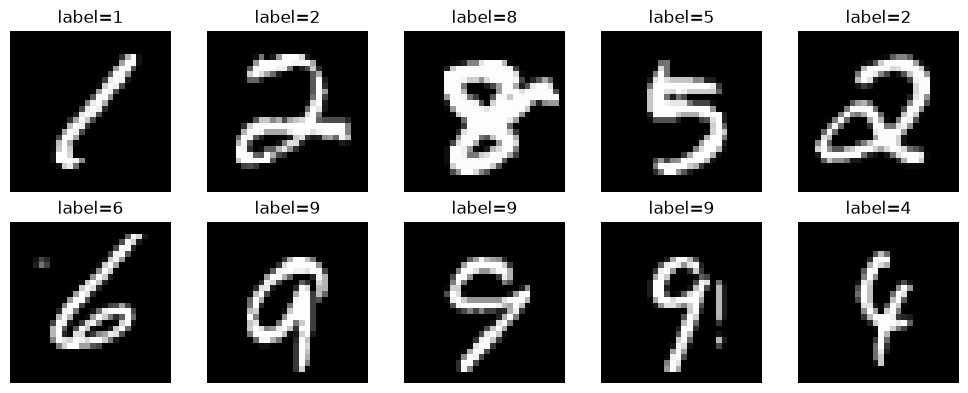

In [48]:

# MNIST 데이터셋의 이미지 샘플을 시각화함
# fig는 matplotlib의 Figure 객체로, 여러 개의 서브플롯을 포함할 수 있음
# axes는 각 서브플롯에 대한 Axes 객체 배열임
# 2x5 형태의 서브플롯을 생성하고, 첫 10개의 이미지와 레이블을 시각화함
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# axes.flat는 2차원 배열인 axes를 1차원으로 평탄화하여 반복문에서 사용하기 위함
# 10개의 이미지와 레이블을 반복문에서 가져옴
for axis, image, label in zip(axes.flat, images[:10], labels[:10]):
    restored = image.squeeze(0) * 0.3081 + 0.1307
    axis.imshow(restored, cmap='gray', vmin=0, vmax=1)
    axis.set_title(f'label={label.item()}')
    axis.axis('off')
plt.tight_layout()
plt.show()

## 4. CNN 모델 정의

두 번의 합성곱과 pooling으로 이미지 특징을 추출하고, 펼친 특징을 두 개의 Linear 계층에 통과시켜 숫자 10개의 logit을 만듭니다.

In [76]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 입력 x 는 (배치 크기, 채널 수, 이미지 높이, 이미지 너비)의 형태를 가짐
        # 즉, 128, 1, 28, 28 (배치 크기, 채널 수, 이미지 높이, 이미지 너비)의 형태를 가짐
        # 출력 y 는 (배치 크기, 클래스 수)의 형태를 가짐
        self.features = nn.Sequential(
            # 1번째 합성곱: (B, 1, 28, 28) → (B, 64, 28, 28)
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            # 2번째 합성곱: 크기를 유지하며 특징을 추가로 추출
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (B, 64, 14, 14)

            # 3번째 합성곱
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            # 4번째 합성곱
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (B, 128, 7, 7)

            # 5번째 합성곱
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),       # (B, 256, 7, 7)
        )
        self.classifier = nn.Sequential(
            # flatten 층을 추가하여 2차원 특징 맵을 1차원 벡터로 변환함 
            # 변환 하는 이유는 FC 층이 1차원 벡터를 입력으로 받기 때문임
            nn.Flatten(),
            # 256개의 3x3 크기의 특징 맵을 1차원 벡터로 변환한 크기임 갯수는 배치 사이즈인 128임
            nn.Linear(256 * 7 * 7, 128),
            nn.ReLU(),
            # 20%의 확률로 뉴런을 비활성화하여 과적합을 방지함
            nn.Dropout(0.2),
            # 출력 클래스 수는 10임 (0~9 숫자)
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCNN().to(DEVICE)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
parameters: 2161226


## 5. 계층을 지날 때 shape 추적

CNN 오류의 상당수는 Linear 계층에 들어가는 크기를 잘못 계산해서 생깁니다. 실제 배치 하나를 통과시키며 shape를 확인합니다.

In [77]:
x = images[:4].to(DEVICE)
print('input'.ljust(22), tuple(x.shape))
for layer in model.features:
    x = layer(x)
    print(layer.__class__.__name__.ljust(22), tuple(x.shape))
for layer in model.classifier:
    x = layer(x)
    print(layer.__class__.__name__.ljust(22), tuple(x.shape))

input                  (4, 1, 28, 28)
Conv2d                 (4, 64, 28, 28)
ReLU                   (4, 64, 28, 28)
Conv2d                 (4, 64, 28, 28)
ReLU                   (4, 64, 28, 28)
MaxPool2d              (4, 64, 14, 14)
Conv2d                 (4, 128, 14, 14)
ReLU                   (4, 128, 14, 14)
Conv2d                 (4, 128, 14, 14)
ReLU                   (4, 128, 14, 14)
MaxPool2d              (4, 128, 7, 7)
Conv2d                 (4, 256, 7, 7)
ReLU                   (4, 256, 7, 7)
Flatten                (4, 12544)
Linear                 (4, 128)
ReLU                   (4, 128)
Dropout                (4, 128)
Linear                 (4, 10)


## 6. 학습과 평가

한 batch마다 gradient 초기화 → 순전파 → 손실 → 역전파 → 가중치 갱신을 반복합니다. 평가할 때는 `eval()`과 `inference_mode()`로 가중치를 바꾸지 않습니다.

In [78]:

# 손실함수 정의 (CrossEntropyLoss는 다중 클래스 분류 문제에서 사용됨)
criterion = nn.CrossEntropyLoss()
# 최적화 함수 정의 (Adam은 적응형 학습률을 사용하는 최적화 알고리즘임)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# 학습 과정에서의 손실과 정확도를 기록하기 위한 리스트
history = []

# 평가 함수 정의 (모델의 성능을 검증 데이터셋에서 평가함)
# 한 epoch 동안의 평가를 수행함
# 평가 결과로 평균 손실과 정확도를 반환함
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.inference_mode():
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(DEVICE)
            batch_labels = batch_labels.to(DEVICE)
            logits = model(batch_images)
            total_loss += criterion(logits, batch_labels).item() * batch_labels.size(0)
            correct += (logits.argmax(dim=1) == batch_labels).sum().item()
            total += batch_labels.size(0)
    return total_loss / total, correct / total

for epoch in range(1, EPOCHS + 1):
    # 학습 모드를 활성화함 (드롭아웃 등 학습 전용 동작을 수행하도록 함)
    model.train()
    # 한 epoch 동안의 학습 손실을 기록하기 위한 변수 초기화
    running_loss = 0.0
    # 배치 단위로 학습 데이터를 반복함, train_loader에서 데이터를 가져옴
    for batch_images, batch_labels in train_loader:
        # 배치 데이터를 장치(GPU 또는 CPU)로 이동시킴
        # 이동시킨다의 의미는 데이터를 GPU 또는 CPU로 옮겨서 모델이 해당 장치에서 연산을 수행하도록 함
        batch_images = batch_images.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)
        # 옵티마이저의 기울기 초기화 (이전 배치에서 계산된 기울기를 제거함)
        optimizer.zero_grad(set_to_none=True)
        # 모델에 배치 데이터를 입력하여 예측(logits)을 계산함
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)
        # 역전파
        loss.backward()
        # 기울기 업데이트 (모델의 파라미터를 최적화함)
        optimizer.step()

        # 배치 손실을 누적하여 epoch 동안의 학습 손실을 계산함
        running_loss += loss.item() * batch_labels.size(0)

    # epoch 동안의 평균 학습 손실 계산, train_loss에 저장
    train_loss = running_loss / len(train_dataset)
    # 검증 데이터셋에서 모델 평가, test_loss와 test_accuracy에 저장
    test_loss, test_accuracy = evaluate(model, test_loader)
    # 학습 및 평가 결과를 기록
    history.append((train_loss, test_loss, test_accuracy))
    # epoch 결과 출력   
    print(
        f'epoch={epoch:02d} train_loss={train_loss:.4f} '
        f'test_loss={test_loss:.4f} accuracy={test_accuracy:.2%}'
    )

epoch=01 train_loss=0.1646 test_loss=0.0357 accuracy=98.86%
epoch=02 train_loss=0.0410 test_loss=0.0400 accuracy=98.87%
epoch=03 train_loss=0.0311 test_loss=0.0300 accuracy=99.08%
epoch=04 train_loss=0.0247 test_loss=0.0223 accuracy=99.33%
epoch=05 train_loss=0.0179 test_loss=0.0229 accuracy=99.41%
epoch=06 train_loss=0.0168 test_loss=0.0191 accuracy=99.29%
epoch=07 train_loss=0.0146 test_loss=0.0235 accuracy=99.35%
epoch=08 train_loss=0.0115 test_loss=0.0251 accuracy=99.30%
epoch=09 train_loss=0.0125 test_loss=0.0244 accuracy=99.25%
epoch=10 train_loss=0.0096 test_loss=0.0234 accuracy=99.42%


## 7. 예측 결과 확인

정확도뿐 아니라 어떤 글씨를 틀리는지 직접 확인합니다. `true`와 `pred`가 다르면 오분류입니다.

Evaluating the model on test images...
torch.Size([128, 1, 28, 28]) torch.Size([128])


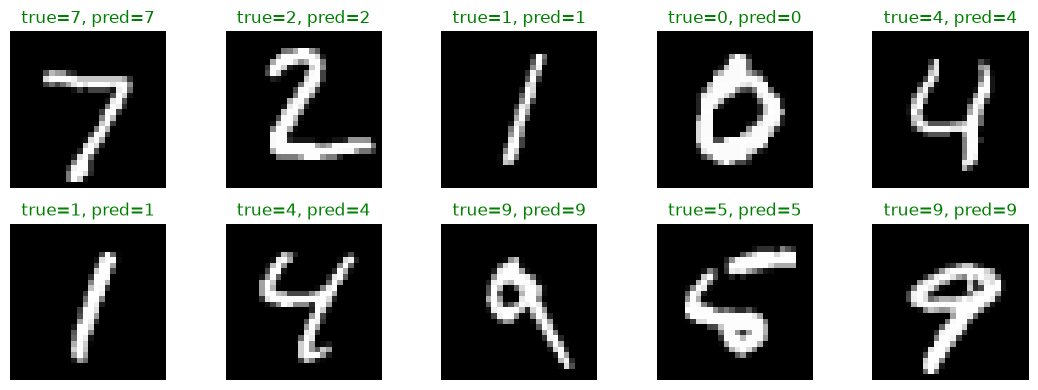

In [79]:
test_images, test_labels = next(iter(test_loader))
# 모델을 평가 모드로 전환 (드롭아웃 등 학습 전용 동작을 비활성화함)
print("Evaluating the model on test images...")
print(test_images.shape, test_labels.shape)
model.eval()
with torch.inference_mode():
    predictions = model(test_images.to(DEVICE)).argmax(dim=1).cpu()

# 시각화 표 (2행 5열), 전체 fig 사이즈 11, 4 인치
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
# 앞에서부터 10개의 테스트 이미지를 시각화함
for axis, image, label, prediction in zip(
    axes.flat, test_images[:10], test_labels[:10], predictions[:10]
):
    # 이미지 복원 (정규화된 값을 원래 값으로 되돌림), 평균과 표준편차를 사용함
    restored = image.squeeze(0) * 0.3081 + 0.1307
    # 이미지를 시각화함, 흑백으로 표시하고 값의 범위를 0에서 1로 설정함
    axis.imshow(restored, cmap='gray', vmin=0, vmax=1)
    # 제목 색상을 설정함 (정답과 예측이 일치하면 초록색, 그렇지 않으면 빨간색)
    color = 'green' if label.item() == prediction.item() else 'red'
    axis.set_title(f'true={label.item()}, pred={prediction.item()}', color=color)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 8. 모델 저장

가중치와 학습 설정을 `/outputs`에 저장합니다. 이 경로는 호스트의 `outputs/`와 연결되어 컨테이너를 종료해도 남습니다.

In [80]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = OUTPUT_DIR / 'mnist_cnn_notebook.pt'
torch.save({
    'model_state': model.state_dict(),
    'config': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'seed': SEED,
    },
    'history': history,
}, checkpoint_path)
print('saved:', checkpoint_path)


saved: /workspace/outputs/notebooks/cnn/mnist_cnn_notebook.pt


## 9. 저장된 모델을 불러와 예측하기

저장 파일에는 모델 구조가 아니라 가중치(`model_state`)가 들어 있으므로, 같은 `SmallCNN` 구조를 만든 뒤 가중치를 넣습니다.

커널을 새로 시작했다면 **1번(라이브러리와 설정), 2번(데이터 준비), 4번(모델 정의)**의 코드 셀을 먼저 실행하고 아래 셀을 실행하세요. 학습 셀과 저장 셀을 다시 실행할 필요는 없습니다. 기존 저장 파일이 있어야 하며, 입력에는 학습 때와 같은 `transform`을 적용합니다.


불러온 파일: /workspace/outputs/notebooks/cnn/mnist_cnn_notebook.pt
실제 정답: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 4, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5]
모델 예측: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 9, 4, 4, 9, 2, 5, 4, 7, 6, 7, 9, 0, 5]
정답률: 0.9921875


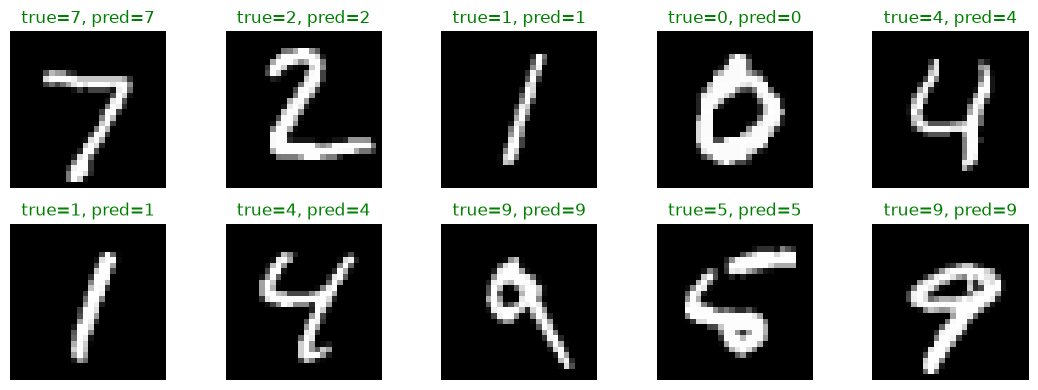

In [81]:
# 1. 저장 파일 읽기 (GPU에서 저장한 파일도 CPU에서 불러올 수 있음)
checkpoint_path = OUTPUT_DIR / 'mnist_cnn_notebook.pt'
if not checkpoint_path.is_file():
    raise FileNotFoundError(f'저장된 모델이 없습니다. 먼저 학습 후 8번 저장 셀을 실행하세요: {checkpoint_path}')

# 1-1. 저장된 체크포인트 파일을 불러옴
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)

# 2. 학습 때와 같은 구조를 만들고 저장된 가중치를 적용
loaded_model = SmallCNN()

# 2-1. 저장된 가중치를 모델에 적용, load_state_dict 사용
# load_state_dict는 모델의 가중치를 불러오는 함수로, 저장된 상태를 현재 모델에 적용함
loaded_model.load_state_dict(checkpoint['model_state'])
# gpu로 모델을 이동시킴 (만약 사용 가능한 경우)
loaded_model = loaded_model.to(DEVICE)
# 모델을 평가 모드로 전환 (드롭아웃 등 학습 전용 동작을 비활성화)
loaded_model.eval()

# 3. 테스트 이미지 10장을 불러온 모델로 예측 (재학습하지 않음)
test_images, test_labels = next(iter(test_loader))
sample_images = test_images[:10000]
sample_labels = test_labels[:10000]

# 추론 모드에서는 기울기 계산을 위한 기록을 생략하여
# 메모리 사용과 계산 비용을 줄임 (with는 반복문이 아님)
with torch.inference_mode():
    predictions = loaded_model(sample_images.to(DEVICE)).argmax(dim=1).cpu()

print('불러온 파일:', checkpoint_path)
print('실제 정답:', sample_labels.tolist())
print('모델 예측:', predictions.tolist())
print('정답률:', (predictions == sample_labels).float().mean().item())
# 4. 이미지와 예측 결과 표시
fig, axes = plt.subplots(2, 5, figsize=(11, 4))
for axis in axes.flat:
    axis.axis('off')
for axis, image, label, prediction in zip(
    axes.flat, sample_images, sample_labels, predictions
):
    restored = image.squeeze(0) * 0.3081 + 0.1307
    axis.imshow(restored, cmap='gray', vmin=0, vmax=1)
    color = 'green' if label.item() == prediction.item() else 'red'
    axis.set_title(f'true={label.item()}, pred={prediction.item()}', color=color)
plt.tight_layout()
plt.show()


## 다음 실험

1. `QUICK_RUN = False`로 바꾸고 정확도 변화를 확인하세요.
2. `EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE` 중 하나만 바꿔 결과를 비교하세요.
3. `Dropout(0.2)`를 제거했을 때 학습과 테스트 성능 차이가 어떻게 변하는지 확인하세요.
4. 첫 번째 합성곱의 출력 채널을 32에서 16으로 바꾸고 파라미터 수를 비교하세요.